# Flow Matching: Straight Targets, Curved Paths

The lecture claims something that sounds wrong at first: the flow-matching
*target* is a straight line, yet its *sampling paths* are the most curved of
the three methods we compare. This notebook reproduces that measurement.

We train, on the same 2-D target and with the same network:

1. a **diffusion** model, sampled with DDIM;
2. a **flow-matching** model on independently paired $(x_0, x_1)$;
3. one **reflow** step on top of it --- that is, rectified flow.

and measure *straightness* $=$ path length $\div$ endpoint distance, so
$1.00$ means exactly straight.

**The question to keep in view:** what actually makes a sampling path
straight?

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 26523
T = 1000
BATCH = 256
torch.manual_seed(SEED)


class VelocityNet(nn.Module):
    """f(x, t) -> R^2, with a smooth embedding of the time argument."""

    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + 4, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, 2),
        )

    def forward(self, x, t):
        t = t.reshape(-1, 1)
        feats = torch.cat([x, t, torch.sin(2 * np.pi * t),
                           torch.cos(2 * np.pi * t), t ** 2], dim=1)
        return self.net(feats)


def noise_schedule(steps=T):
    beta = torch.linspace(1e-4, 0.02, steps)
    return beta, torch.cumprod(1 - beta, dim=0)

## Targets

Four 2-D distributions of increasing awkwardness. The last one --- a single
distant blob --- is the control: with only one mode, almost no pairs cross.

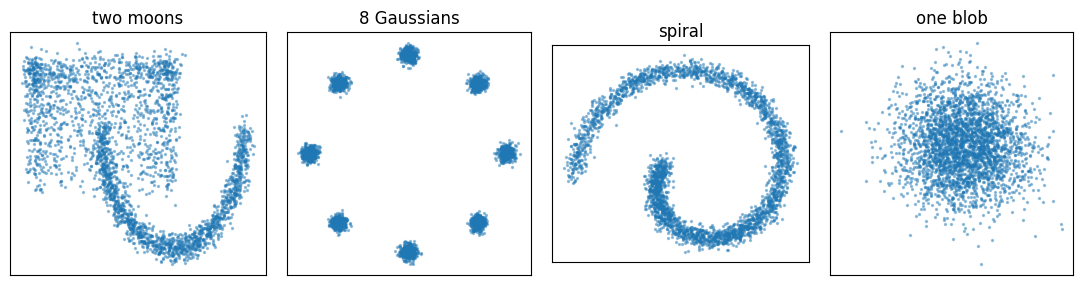

In [2]:
def moons(n, noise=0.06, seed=9):
    rng = np.random.default_rng(seed)
    half = n // 2
    a = np.c_[np.cos(rng.uniform(0, np.pi, half)),
              np.sin(rng.uniform(0, np.pi, half))]
    ang = rng.uniform(0, np.pi, n - half)
    b = np.c_[1 - np.cos(ang), 0.5 - np.sin(ang)]
    pts = np.r_[a, b] + rng.normal(scale=noise, size=(n, 2))
    return ((pts - pts.mean(0)) / pts.std(0)).astype(np.float32)


def ring(n, k=8, r=2.4, s=0.10, seed=0):
    rng = np.random.default_rng(seed)
    a = 2 * np.pi * rng.integers(0, k, n) / k
    return (np.c_[r * np.cos(a), r * np.sin(a)]
            + rng.normal(0, s, (n, 2))).astype(np.float32)


def spiral(n, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(0.3, 1.0, n) * 3 * np.pi
    r = 0.28 * t
    return (np.c_[r * np.cos(t), r * np.sin(t)] / 2.2
            + rng.normal(0, 0.05, (n, 2))).astype(np.float32)


def blob(n, seed=0):
    rng = np.random.default_rng(seed)
    return (rng.normal(0, 0.25, (n, 2)) + np.array([3.2, 0.0])).astype(np.float32)


TARGETS = {"two moons": moons, "8 Gaussians": ring, "spiral": spiral,
           "one blob": blob}

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
for ax, (name, gen) in zip(axes, TARGETS.items()):
    pts = gen(3000)
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Training

Two losses. The diffusion model regresses on the noise that was added:

$$\mathcal L_{\rm DM}=\mathbb E\bigl\|\varepsilon-\epsilon_\theta(x_t,t)\bigr\|^2,
\qquad x_t=\sqrt{\overline\alpha_t}\,x_0+\sqrt{1-\overline\alpha_t}\,\varepsilon .$$

The flow model regresses on the velocity of the straight path between a pair:

$$\mathcal L_{\rm CFM}=\mathbb E\bigl\|v_\theta(x_t,t)-(x_1-x_0)\bigr\|^2,
\qquad x_t=(1-t)\,x_0+t\,x_1 .$$

Note that `fit_pairs` takes the coupling as an argument. Passing an
*independent* pairing gives flow matching; passing the pairing induced by an
already-trained field gives a reflow step. That one argument is the whole
difference between flow matching and rectified flow.

In [3]:
def fit_diffusion(data, seed=0, steps=4000):
    torch.manual_seed(seed)
    model, _ab = VelocityNet(), None
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    _, alpha_bar = noise_schedule()
    d = torch.tensor(data)
    for _ in range(steps):
        b = d[torch.randint(0, len(d), (BATCH,))]
        t = torch.randint(0, T, (BATCH,))
        eps = torch.randn_like(b)
        a = alpha_bar[t].unsqueeze(1)
        xt = a.sqrt() * b + (1 - a).sqrt() * eps
        loss = ((model(xt, t.float() / T) - eps) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model


def fit_pairs(z0, z1, seed=0, steps=4000):
    """Regress on the pair velocity. The coupling (z0, z1) is the input."""
    torch.manual_seed(seed)
    model = VelocityNet()
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    for _ in range(steps):
        i = torch.randint(0, len(z0), (BATCH,))
        a, b = z0[i], z1[i]
        t = torch.rand(BATCH, 1)
        xt = (1 - t) * a + t * b
        loss = ((model(xt, t.squeeze(1)) - (b - a)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model

## Samplers, and the straightness measure

DDIM reads off the implied clean point and re-noises it to the next level.
Euler follows the velocity field. Both are deterministic given the starting
noise, which is what lets us compare their trajectories point by point.

In [4]:
@torch.no_grad()
def ddim_paths(model, n=360, steps=60, seed=11):
    torch.manual_seed(seed)
    _, alpha_bar = noise_schedule()
    keep = torch.linspace(0, T - 1, steps).long().flip(0)
    x = torch.randn(n, 2)
    traj = [x.numpy().copy()]
    for k, t in enumerate(keep):
        a_bar = alpha_bar[t]
        a_prev = alpha_bar[keep[k + 1]] if k + 1 < len(keep) else torch.tensor(1.0)
        eps = model(x, torch.full((n,), float(t) / T))
        x0 = ((x - (1 - a_bar).sqrt() * eps) / a_bar.sqrt()).clamp(-6, 6)
        x = a_prev.sqrt() * x0 + (1 - a_prev).sqrt() * eps
        traj.append(x.numpy().copy())
    return np.array(traj)


@torch.no_grad()
def euler_paths(model, x, steps=60):
    traj = [x.numpy().copy()]
    dt = 1.0 / steps
    for k in range(steps):
        x = x + dt * model(x, torch.full((len(x),), k * dt))
        traj.append(x.numpy().copy())
    return x, np.array(traj)


def straightness(traj):
    """Path length over endpoint distance; 1.0 is exactly straight."""
    seg = np.linalg.norm(np.diff(traj, axis=0), axis=2).sum(axis=0)
    direct = np.linalg.norm(traj[-1] - traj[0], axis=1)
    return float(np.mean(seg / np.maximum(direct, 1e-6)))

## One target, three methods

Train all three on the spiral --- the target where the gap is widest --- and
plot the trajectories with their measured straightness.

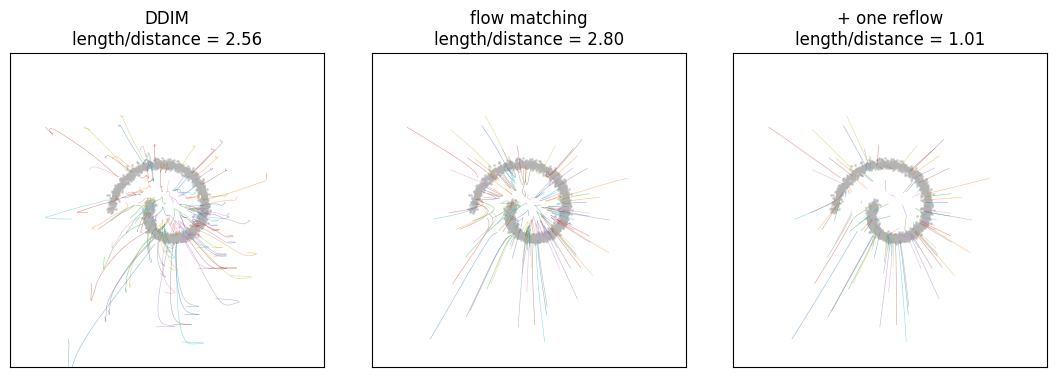

In [5]:
def three_methods(gen, seed=1):
    data = gen(20_000)
    diffusion = fit_diffusion(data)

    torch.manual_seed(3)
    z0 = torch.randn(20_000, 2)
    z1 = torch.tensor(data)[torch.randperm(20_000)]     # independent pairing
    flow = fit_pairs(z0, z1, seed=seed)

    induced, _ = euler_paths(flow, z0.clone(), steps=100)   # the field's own map
    reflowed = fit_pairs(z0, induced, seed=seed + 1)        # rectified flow

    torch.manual_seed(11)
    start = torch.randn(360, 2)
    return {
        "DDIM": ddim_paths(diffusion),
        "flow matching": euler_paths(flow, start.clone())[1],
        "+ one reflow": euler_paths(reflowed, start.clone())[1],
    }


paths = three_methods(spiral)
target = spiral(2500, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7))
for ax, (name, traj) in zip(axes, paths.items()):
    ax.scatter(target[:, 0], target[:, 1], s=1, color="0.7", alpha=0.5)
    for k in range(0, traj.shape[1], 3):
        ax.plot(traj[:, k, 0], traj[:, k, 1], linewidth=0.4, alpha=0.5)
    ax.set_title(f"{name}\nlength/distance = {straightness(traj):.2f}")
    ax.set_xlim(-3.4, 3.4); ax.set_ylim(-3.4, 3.4)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Is it a quirk of one target?

Run the same three fits on all four distributions. This trains twelve models,
so it takes a few minutes.

two moons      DDIM  1.51  flow matching  2.44  + one reflow  1.00


8 Gaussians    DDIM  1.60  flow matching  1.48  + one reflow  1.00


spiral         DDIM  2.56  flow matching  2.80  + one reflow  1.01


one blob       DDIM  1.08  flow matching  1.00  + one reflow  1.00


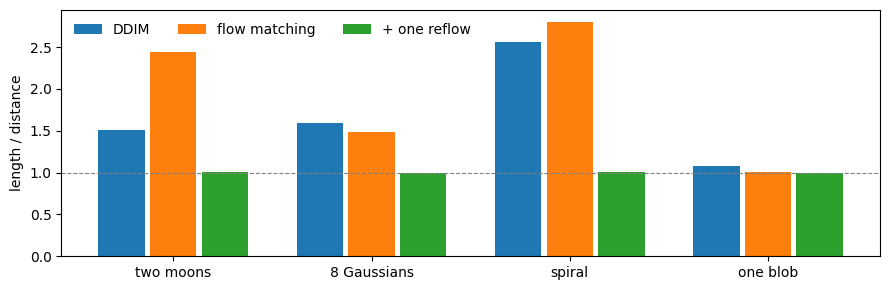

In [6]:
rows = {}
for name, gen in TARGETS.items():
    rows[name] = {k: straightness(v) for k, v in three_methods(gen).items()}
    print(f"{name:14s} " + "  ".join(f"{k} {v:5.2f}" for k, v in rows[name].items()))

labels = list(TARGETS)
methods = ["DDIM", "flow matching", "+ one reflow"]
pos, width = np.arange(len(labels)), 0.26
fig, ax = plt.subplots(figsize=(9, 3))
for j, m in enumerate(methods):
    ax.bar(pos + (j - 1) * width, [rows[n][m] for n in labels], width * 0.9, label=m)
ax.axhline(1.0, ls="--", color="0.5", lw=0.8)
ax.set_xticks(pos); ax.set_xticklabels(labels)
ax.set_ylabel("length / distance"); ax.legend(ncol=3, frameon=False)
plt.tight_layout()

## What the numbers say

Read the bars before reading on.

DDIM is **straighter than flow matching on every target**, even though flow
matching regresses on a perfectly straight target. The reason is that
straightness of the *conditional* path says nothing about the *sampling* path:
with an independent pairing, a great many pairs cross, and a deterministic
field cannot let two trajectories cross. It returns the average velocity at
each point and bends around the conflict.

The "one blob" column is the control. A single distant mode produces almost no
crossings, and there all three methods sit at $1.00$ together.

Reflow removes the crossings by re-pairing each $x_0$ with the $x_1$ its own
solver sends it to. Those pairs are already transported by the field, so there
is nothing left to average, and the paths straighten to $1.00$.

### Things to try

- Increase the number of reflow steps. Does straightness keep improving?
- Compare samples at 2, 5 and 10 Euler steps before and after reflow. A
  straighter path should tolerate a coarser solver --- check whether it does.
- Reflow preserves the marginals in theory. Verify it: compare the sample
  distributions before and after, not just the trajectories.
- Replace the independent pairing with one matched by nearest neighbour. How
  much of reflow's benefit does that recover?